<a href="https://colab.research.google.com/github/Grandi-Luca/AAUTExercises/blob/main/clustering_copy_for_students_aa_21_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Grandi-Luca/AAUTExercises.git

Cloning into 'AAUTExercises'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 53 (delta 17), reused 23 (delta 4), pack-reused 0
Receiving objects: 100% (53/53), 2.56 MiB | 5.57 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [ ]:
!mv -v AAUTExercises/Jupyter\ Notebooks/Datasets/* ./

renamed 'AAUTExercises/Jupyter Notebooks/Datasets/3-clusters.csv' -> './3-clusters.csv'
renamed 'AAUTExercises/Jupyter Notebooks/Datasets/CURE-complete.csv' -> './CURE-complete.csv'
renamed 'AAUTExercises/Jupyter Notebooks/Datasets/dataset-DBSCAN.csv' -> './dataset-DBSCAN.csv'


# Exercizes on clustering

Here you can find a program to read a data file in csv format.

The data file has the following heading:
    number of samples, number of features
    list of the names of the features (separated by comma)
    
The remaining lines contain an example per row.
For each row there is a list of real numbers (commas separated) which are the feature values.   

In [1]:
import csv
import sys
from os.path import join

import numpy as np

# this function reads the data file, loads the configuration attributes specifiefd in the heading
# (numer of examples and features), the list of feature names
# and loads the data in a matrix named data
def load_data(file_path, file_name):
   with open(join(file_path, file_name)) as csv_file:
       data_file = csv.reader(csv_file,delimiter=',')
       temp1 = next(data_file)
       n_samples = int(temp1[0])
       print("n_samples=")
       print(n_samples)
       n_features = int(temp1[1])
       temp2 = next(data_file)
       feature_names = np.array(temp2[:n_features])

       data_list = [iter for iter in data_file]

       data = np.asarray(data_list, dtype=np.float64)

   return(data,feature_names,n_samples,n_features)

# The main program reads the input file containing the dataset
# file_path is the file path where the file with the data to be read are located
# we assume the file contains an example per line
# each example is a list of real values separated by a comma (csv format)
# The first line of the file contains the heading with:
# N_samples,n_features,
# The second line contains the feature names separated by a comma

#file_path="content/"
file_path="./"
# all the three datasets contain data points on (x,y)
file_name1="3-clusters.csv"
file_name2="dataset-DBSCAN.csv"
file_name3="CURE-complete.csv"
data1,feature_names1,n_samples1,n_features1 = load_data(file_path, file_name1)
data2,feature_names2,n_samples2,n_features2 = load_data(file_path, file_name2)
data3,feature_names3,n_samples3,n_features3 = load_data(file_path, file_name3)
print("dataset n. 1: n samples, n features")
print(n_samples1, n_features1)
print("dataset n. 2: n samples, n features")
print(n_samples2, n_features2)
print("dataset n. 3: n samples, n features")
print(n_samples3, n_features3)

n_samples=
150
n_samples=
6118
n_samples=
86558
dataset n. 1: n samples, n features
150 2
dataset n. 2: n samples, n features
6118 2
dataset n. 3: n samples, n features
86558 2


The following program plots the dataset n.1

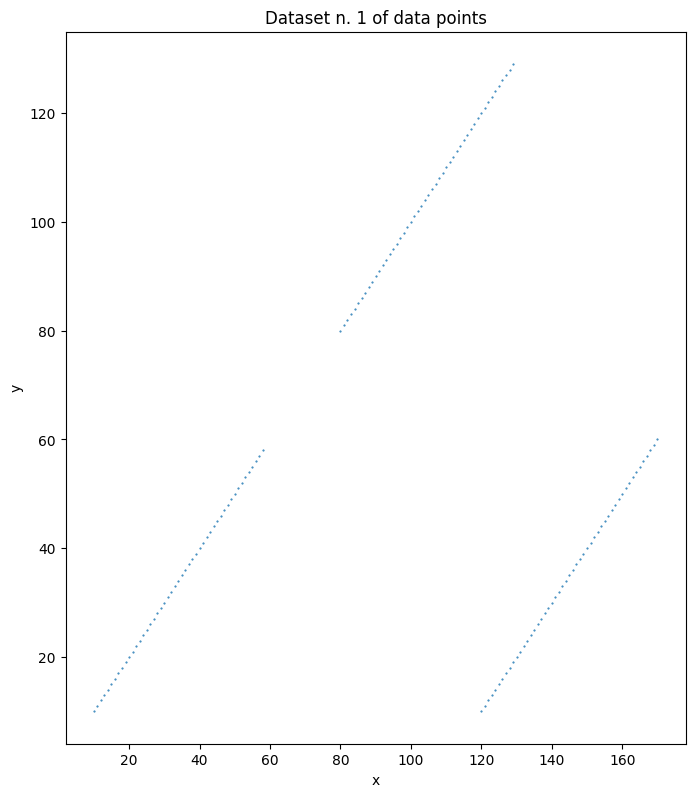

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111)
fig.subplots_adjust(top=1)
ax.set_title('Dataset n. 1 of data points')

ax.set_xlabel(feature_names1[0]) # x
ax.set_ylabel(feature_names1[1]) # y

#plot the dataset
plt.plot(data1[:,0], data1[:,1], '.',markersize=1)

plt.show()

The following is the program for plotting the dataset n.2

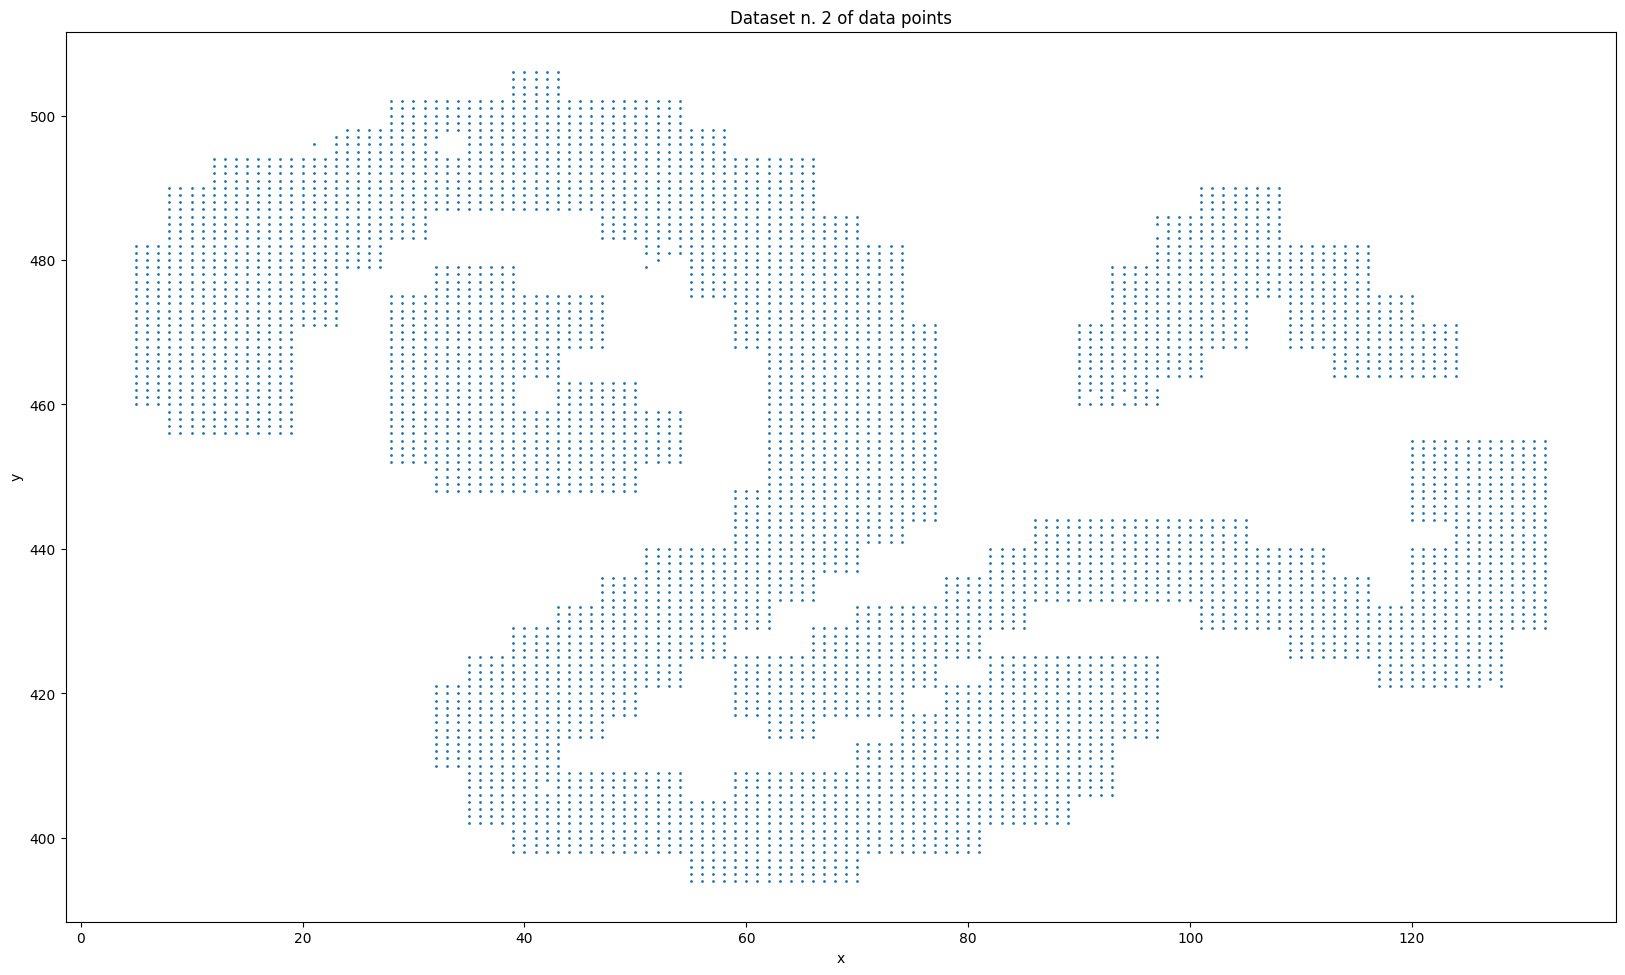

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20,10))

ax = fig.add_subplot(111)
fig.subplots_adjust(top=1)
ax.set_title('Dataset n. 2 of data points')

ax.set_xlabel(feature_names2[0]) # x
ax.set_ylabel(feature_names2[1]) # y

#plot the dataset
plt.plot(data2[:,0], data2[:,1], '.', markersize=2)

plt.show()

The following is the program for plotting the dataset n.3

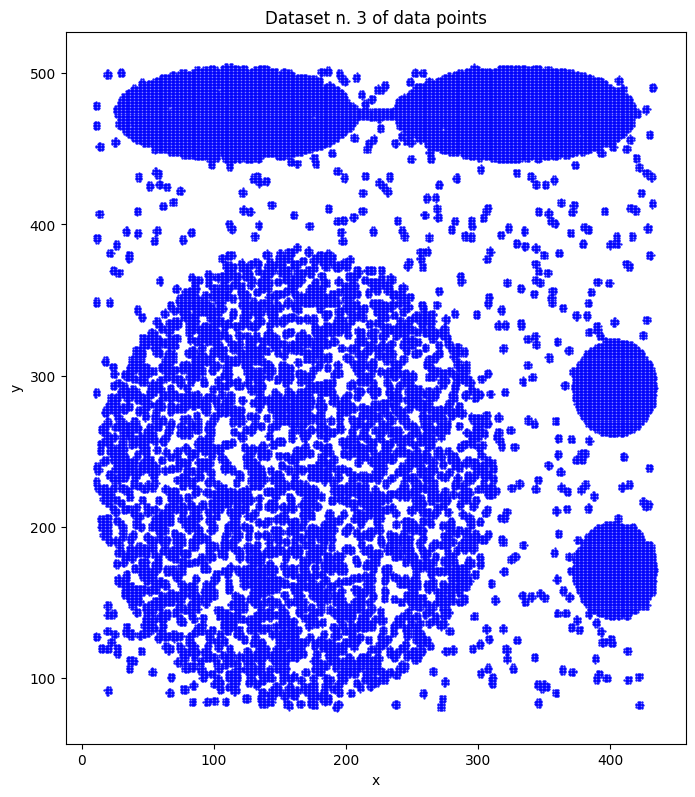

In [4]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111)
fig.subplots_adjust(top=1)
ax.set_title('Dataset n. 3 of data points')

ax.set_xlabel(feature_names3[0]) # x
ax.set_ylabel(feature_names3[1]) # y

#plot the dataset
plt.plot(data3[:,0], data3[:,1], '.', markersize=1.2, markeredgecolor = 'blue')

plt.show()

## In the following program we cluster the dataset n.1 with K-means.
From the plot of dataset n.1 we see 3 separated clusters. Thus k=3.

In [5]:
import csv
import sys
from os.path import join

import numpy as np

def load_data(file_path, file_name):
   with open(join(file_path, file_name)) as csv_file:
       data_file = csv.reader(csv_file,delimiter=',')
       temp1 = next(data_file)
       n_samples = int(temp1[0])
       n_features = int(temp1[1])
       temp2 = next(data_file)
       feature_names = np.array(temp2[:n_features])

       data_list = [iter for iter in data_file]

       data = np.asarray(data_list, dtype=np.float64)

   return(data,feature_names,n_samples,n_features)

# The main program reads the input file containing the dataset
# file_path is the file path where the file with the data to be read are located
# we assume the file contains an example per line
# each example is a list of real values separated by a comma (csv format)
# The first line of the file contains the heading with:
# N_samples,n_features,
# The second line contains the feature names separated by a comma

#file_path="~/meo/Documents/Didattica/Laboratorio-15-16-Jupyter/"
file_path="./"
# all the three datasets contain data points on (x,y)
file_name1="3-clusters.csv"

data1,feature_names1,n_samples1,n_features1 = load_data(file_path, file_name1)

from sklearn.cluster import KMeans

np.random.seed(5)

k=3
kmeans1 = KMeans(n_clusters=k, random_state=0).fit(data1)

i=0
for i in range(n_samples1):
    print("Example n."+str(i)+"=("+str(data1[i,0])+","+str(data1[i,1])+")")
    print("in cluster n."+str(kmeans1.labels_[i]))

Example n.0=(10.0,10.0)
in cluster n.1
Example n.1=(11.0,11.0)
in cluster n.1
Example n.2=(12.0,12.0)
in cluster n.1
Example n.3=(13.0,13.0)
in cluster n.1
Example n.4=(14.0,14.0)
in cluster n.1
Example n.5=(15.0,15.0)
in cluster n.1
Example n.6=(16.0,16.0)
in cluster n.1
Example n.7=(17.0,17.0)
in cluster n.1
Example n.8=(18.0,18.0)
in cluster n.1
Example n.9=(19.0,19.0)
in cluster n.1
Example n.10=(20.0,20.0)
in cluster n.1
Example n.11=(21.0,21.0)
in cluster n.1
Example n.12=(22.0,22.0)
in cluster n.1
Example n.13=(23.0,23.0)
in cluster n.1
Example n.14=(24.0,24.0)
in cluster n.1
Example n.15=(25.0,25.0)
in cluster n.1
Example n.16=(26.0,26.0)
in cluster n.1
Example n.17=(27.0,27.0)
in cluster n.1
Example n.18=(28.0,28.0)
in cluster n.1
Example n.19=(29.0,29.0)
in cluster n.1
Example n.20=(30.0,30.0)
in cluster n.1
Example n.21=(31.0,31.0)
in cluster n.1
Example n.22=(32.0,32.0)
in cluster n.1
Example n.23=(33.0,33.0)
in cluster n.1
Example n.24=(34.0,34.0)
in cluster n.1
Example n.

In the following program we plot the clusters

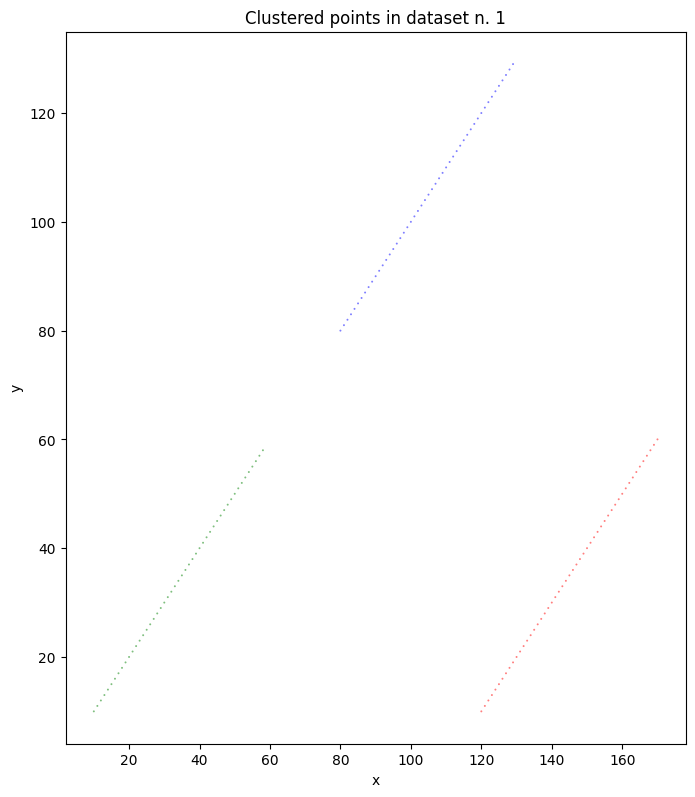

In [6]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111)
fig.subplots_adjust(top=1)
ax.set_title('Clustered points in dataset n. 1')

ax.set_xlabel('x')
ax.set_ylabel('y')

# set the list of colors to be selected when plotting the different clusters
color=['b','g','r','c','m','y','k','w']

#plot the dataset
for clu in range(k):
    # collect the sequence of cooordinates of the points in each given cluster (determined by clu)
    data_list_x = [data1[i,0] for i in range(n_samples1) if kmeans1.labels_[i]==clu]
    data_list_y = [data1[i,1] for i in range(n_samples1) if kmeans1.labels_[i]==clu]
    plt.scatter(data_list_x, data_list_y, s=2, edgecolors='none', c=color[clu], alpha=0.5)

plt.show()

In [7]:
from sklearn.cluster import KMeans

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_graph(data, n_samples, y_pred, k, dataset_name):

  fig = plt.figure(figsize=(8,8))

  ax = fig.add_subplot(111)
  fig.subplots_adjust(top=1)
  ax.set_title(f'Clustered points in {dataset_name}')

  # Remove old lines from plot and plot new one
  [l.remove() for l in ax.lines]

  ax.set_xlabel('x')
  ax.set_ylabel('y')

  # set the list of colors to be selected when plotting the different clusters
  colors = ['b','g','r','c','m','y','k','w']
  if len(colors) < np.unique(y_pred).shape[0]:
    colors.extend(list(mcolors.CSS4_COLORS.values()))

  if len(colors) < np.unique(y_pred).shape[0]:
    colors.extend(list(mcolors.XKCD_COLORS.values()))


  # plot the dataset
  for clu in range(k):
      # collect the sequence of cooordinates of the points in each given cluster (determined by clu)
      data_list_x = [data[i,0] for i in range(n_samples) if y_pred[i]==clu]
      data_list_y = [data[i,1] for i in range(n_samples) if y_pred[i]==clu]
      plt.scatter(data_list_x, data_list_y, s=2, edgecolors='none', c=colors[clu], alpha=1)

  plt.show()

In the following cell I propose you to perform clustering with K-means on dataset2.

In [12]:
k = 3
kmeans2 = KMeans(init="random", n_init="auto", n_clusters=k, random_state=0).fit(data2)

In the following you have to plot clustering results on dataset2.

**Answer:**
how do you explain what it happens?

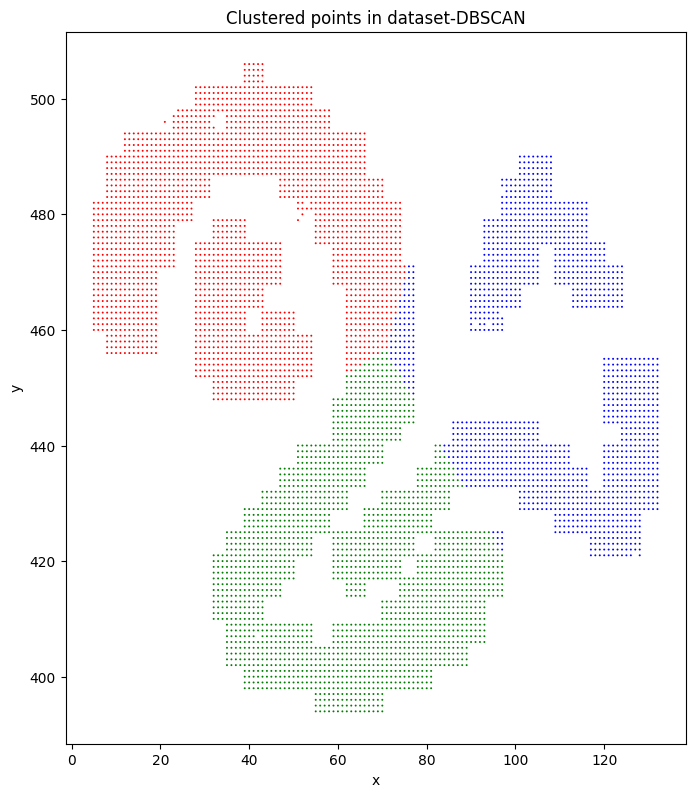

In [13]:
plot_graph(data2, n_samples2, kmeans2.labels_, k, "dataset-DBSCAN")

In the following cell I propose you to perform clustering with K-means on the dataset3.

In [16]:
k = 3
kmeans3 = KMeans(init="random", n_init="auto", n_clusters=k, random_state=0).fit(data3)

In the following cell, I propose you to plot clustering results on dataset3.

**Answer:**
how do you explain what it happens?

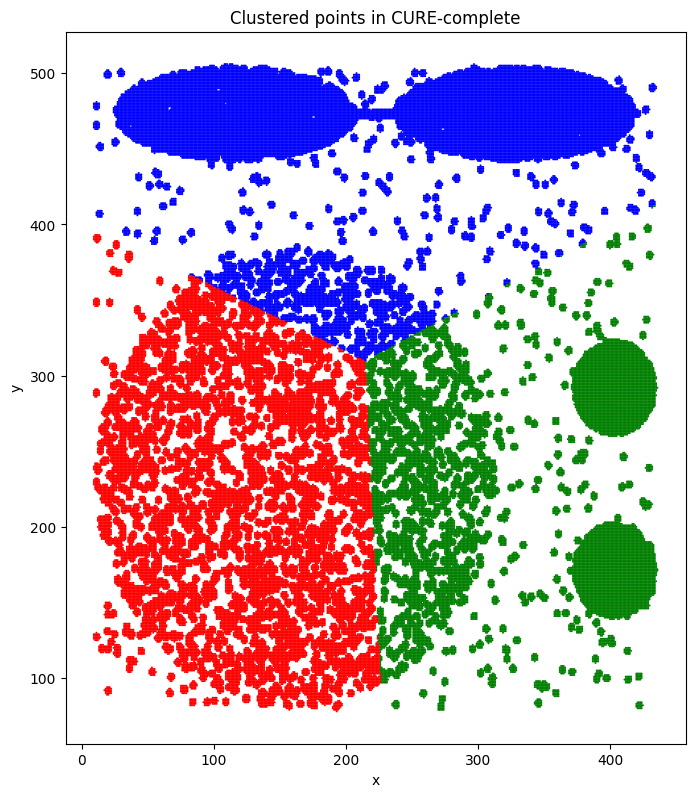

In [17]:
plot_graph(data3, n_samples3, kmeans3.labels_, k, "CURE-complete")

In the following cells I propose you to write a program that computes with a statistical measure of your choice a quantitative evaluation of clusters in the three datasets.

**Note:**
It is advisable to execute K-means a certain number of times (let us try 10 times) and then select the clustering solution that gives the best value of the evaluation measure.

In [28]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import silhouette_score

np.random.seed(5)

k = 3
best_models = []

for dataset, ds_name in [(data1, "3-clusters"), (data2, "dataset-DBSCAN"), (data3, "CURE-complete")]:
    kmeans_models = [KMeans(init="random", n_init=1, n_clusters=k, random_state=np.random.randint(0, 10000)).fit(dataset) for _ in range(10)]

    # Silhouette Score Metric:
    result = [silhouette_score(dataset, model.labels_) for model in kmeans_models]

    best_model = kmeans_models[np.argmax(result)]

    best_models.append((ds_name, best_model, np.max(result), best_model.cluster_centers_))

In [29]:
best_models

[('3-clusters',
  KMeans(init='random', n_clusters=3, n_init=1, random_state=2915),
  np.float64(0.7229402453727759),
  array([[104.5, 104.5],
         [145. ,  35. ],
         [ 34. ,  34. ]])),
 ('dataset-DBSCAN',
  KMeans(init='random', n_clusters=3, n_init=1, random_state=2718),
  np.float64(0.4798818451822113),
  array([[ 38.9394314 , 476.20931191],
         [ 64.29048724, 419.52064965],
         [108.33007813, 452.42122396]])),
 ('CURE-complete',
  KMeans(init='random', n_clusters=3, n_init=1, random_state=4199),
  np.float64(0.3910520541745633),
  array([[321.01305086, 227.95150621],
         [121.05070834, 214.96615696],
         [216.56323406, 442.08557047]]))]

As already done with classification by k-nn, plot in the cell below the quantitative measure of your choice (used above) with respect to an increasing value of k (the number of clusters) so that the best value of k can be selected.

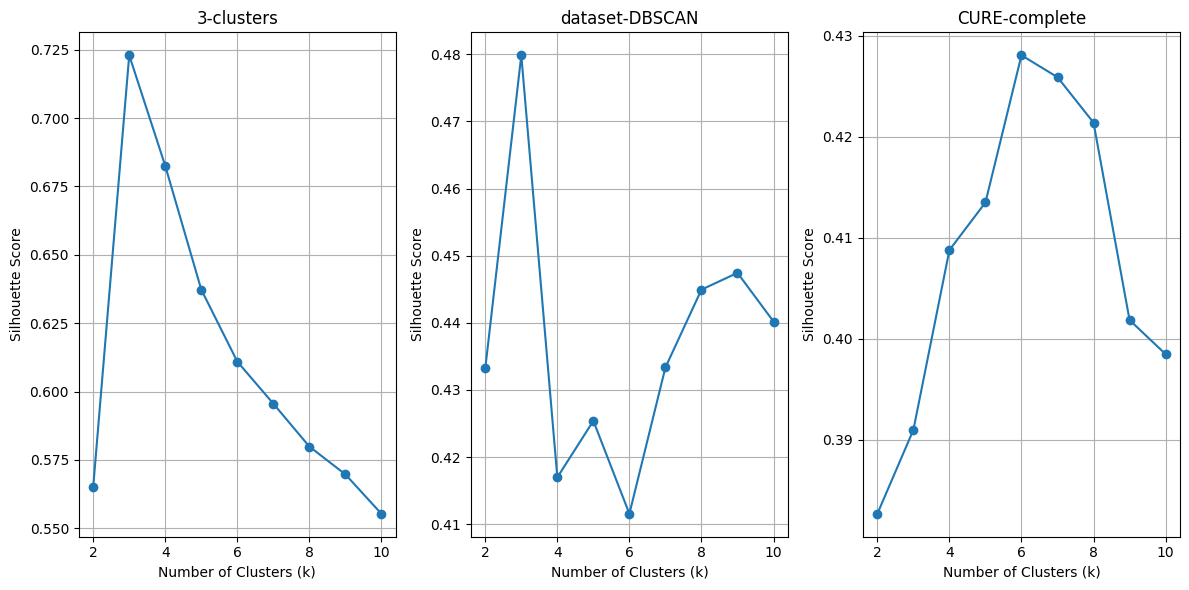

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(5)

# Define a range of values for k (number of clusters)
k_values = range(2, 11)  # You can adjust this range as needed


eval_scores = []

for dataset, dataset_name in [(data1, "3-clusters"), (data2, "dataset-DBSCAN"), (data3, "CURE-complete")]:
    scores = []
    for k in k_values:
        # Fit a K-means model with the current value of k
        kmeans = KMeans(init="random", n_init=10, n_clusters=k)
        kmeans.fit(dataset)

        # Silhouette Score Metric:
        silhouette_avg = silhouette_score(dataset, kmeans.labels_)
        scores.append(silhouette_avg)

    # Store the scores for this dataset
    eval_scores.append(scores)

# Plot the evaluation metric Silhouette Score for each dataset
plt.figure(figsize=(12, 6))

for i, dataset_name in enumerate(["3-clusters", "dataset-DBSCAN", "CURE-complete"]):
    plt.subplot(1, len(["3-clusters", "dataset-DBSCAN", "CURE-complete"]), i + 1)
    plt.plot(k_values, eval_scores[i], marker='o')
    plt.title(f"{dataset_name}")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)

plt.tight_layout()
plt.show()


In the following cell I propose you to run DBSCAN, instead, on one of the last two datasets: either dataset2 or dataset3.

At the beginning try using a pair of Minpts and Eps of your choice.

**Note:**
If the data is too big, **sample it random, using a factor of 0.1.**

In [55]:
from sklearn.cluster import DBSCAN

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

class DB():
    def __init__(self, name, data, n_samples):
        self.name = name
        self.data = data
        self.n_samples = n_samples

x = [
    ("CURE-complete", DB("CURE-complete", data3, n_samples3)),
    ("dataset-DBSCAN", DB("dataset-DBSCAN", data2, n_samples2))
]


@interact(eps=(0.5,10.0,0.1), min_samples=(2,20,1), dataset=x)
def play_with_dbscan(dataset, eps=1.30, min_samples=5):

    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(dataset.data)

    plot_graph(dataset.data, dataset.n_samples, clustering.labels_, np.unique(clustering.labels_).shape[0], dataset.name)

interactive(children=(Dropdown(description='dataset', options=(('CURE-complete', <__main__.DB object at 0x7e49…

In the following cell I propose you to:

1.   Set *Minpts* to a number (say **10**).
2.   Compute the **reachability distance** of the **10-th nearest neighbour ** for each data-point.
3. Sort the set of reachability distances you obtained in an increasing way.
4. Plot the sorted reachability distances
5. Find the **elbow** of the diagram => it gives the eps value combined with Minpts=10.
6. Try this combined pair of parameters on the dataset you chose, with DBSCAN.

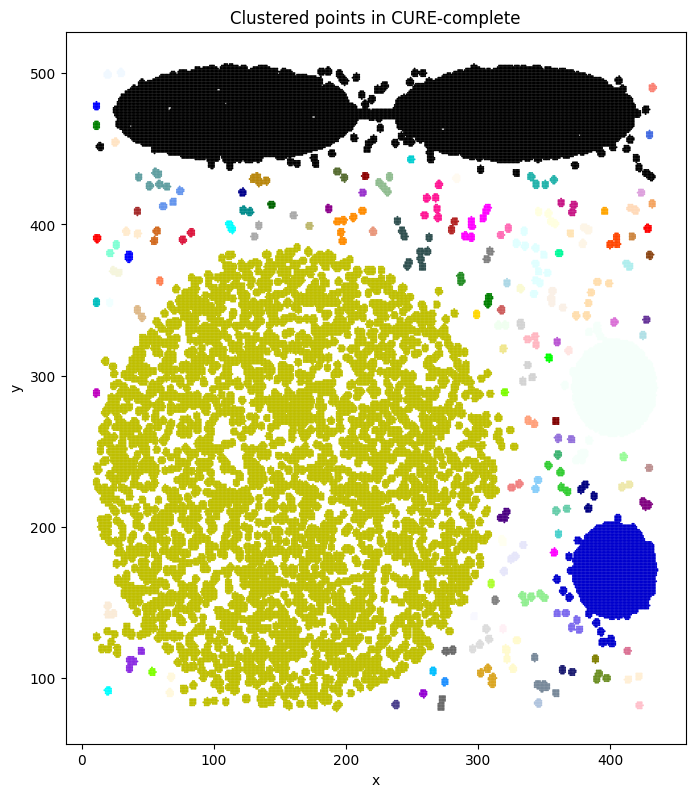

In [32]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=5, min_samples=10).fit(data3)

plot_graph(data3, n_samples3, clustering.labels_, np.unique(clustering.labels_).shape[0], "CURE-complete")

In [40]:
from sklearn.neighbors import NearestNeighbors


# Find the 10th nearest neighbors
nn = NearestNeighbors(n_neighbors=10, metric='euclidean')
nn.fit(data2)

# Compute the reachability distance for each data point
reachability_distances, _ = nn.kneighbors(data2)
# Sort the reachability distances in increasing order
reachability_distances = np.sort(reachability_distances[:, -1])

# Print the reachability distances for each data point
print("Reachability Distances:", reachability_distances)

Reachability Distances: [2. 2. 2. ... 3. 3. 4.]


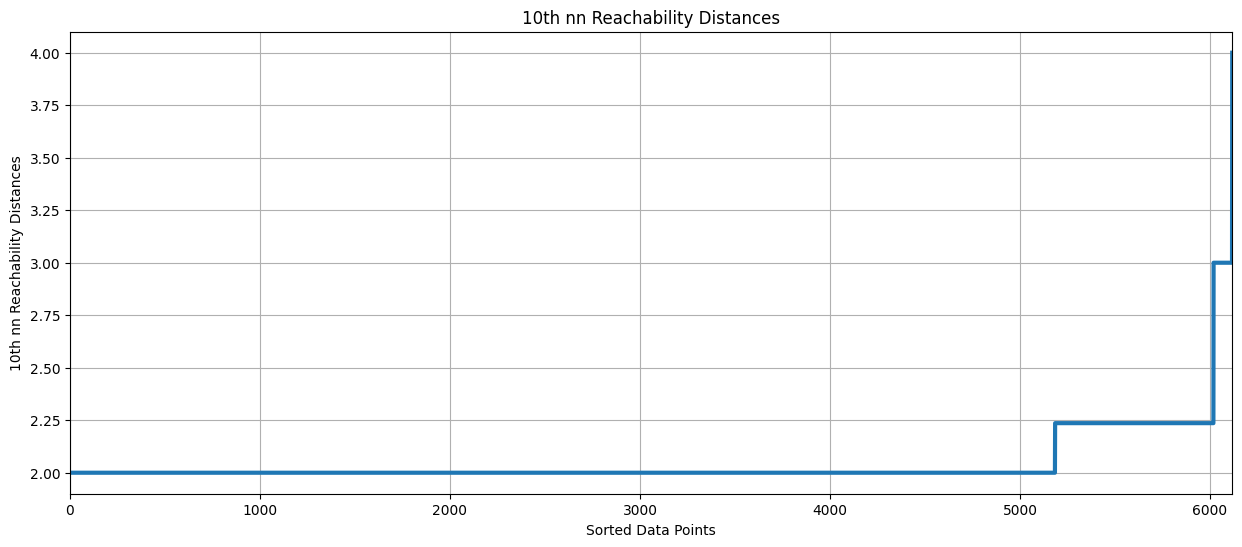

In [41]:
# Create a plot
plt.figure(figsize=(15, 6))

indices = np.arange(reachability_distances.shape[0])
plt.plot(indices, reachability_distances, linewidth=3)
plt.xlim(0, reachability_distances.shape[0])


# Add labels and title
plt.xlabel("Sorted Data Points")
plt.ylabel("10th nn Reachability Distances")
plt.title("10th nn Reachability Distances")

# Show the plot
plt.grid()
plt.show()

In [42]:
%%capture
!pip install kneefinder

In [43]:
import numpy as np
from kneefinder import KneeFinder

kf = KneeFinder(indices, reachability_distances)

knee_x, knee_y = kf.find_knee()

print(f"Knee point: x={knee_x}, y={knee_y}")

Knee point: x=6018.0, y=2.23606797749979


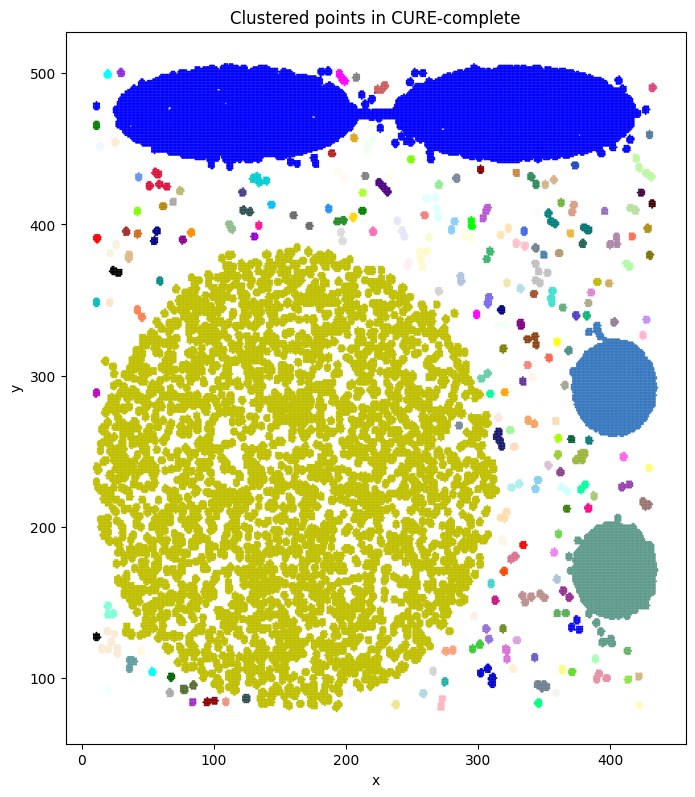

In [38]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=knee_y, min_samples=10).fit(data3)

plot_graph(data3, n_samples3, clustering.labels_, np.unique(clustering.labels_).shape[0], "CURE-complete")